## This notebook uses the trained model to make predictions on test data

**Regex for VTE**: r'dvt|\spe\s|vte|thrombosis|thromboses|thrombus|thrombi|thrombotic|clot|embolus|emboli|thrombophlebitis'

In [60]:
import sys
import numpy as np
from functools import wraps
from typing import overload
from pathlib import Path
import datetime as dt
import os
import pandas as pd
import re
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from notebook_utils import get_parent_dir

sys.path.append(str(get_parent_dir() / "PINES"))

from train_finetune import (
    start_pipeline,
    update_dtype,
    map_column_name,
    get_data
)
    
# Figure aesthetics
%config InlineBackend.figure_format = 'retina'
sns.set_theme()
sns.set_context("talk")
sns.set_style("white")

In [2]:
IN_DIR = get_parent_dir () / "In"
OUT_DIR = get_parent_dir () / "Out"

In [3]:
# Getting events

events = pd.read_parquet(IN_DIR / "prepped_core_7_21_2022.parquet",
                         columns=["MRN", "CANCER_VTE_DATE", "OLD_VTE_DATE"]
                         )\
.pipe(start_pipeline)\
.pipe(update_dtype, dtype={"CANCER_VTE_DATE": "datetime", 
                            "OLD_VTE_DATE": "datetime"})\
.pipe(map_column_name, rename_cols={"MRN": "patient_id",
                                   "CANCER_VTE_DATE": "event_date"})

start_pipeline took=0:00:00.000276 shape=(35391, 3)
update_dtype took=0:00:00.005819 shape=(35391, 3)
map_column_name took=0:00:00.000959 shape=(35391, 3)


## Base Data

In [4]:
train_ids = pd.read_csv(IN_DIR / "train_ids.csv")
val_ids = pd.read_csv(IN_DIR / "val_ids.csv")
dev_ids = pd.read_csv(IN_DIR / "dev_ids.csv")

In [43]:
train_df, val_df, dev_df = get_data()

start_pipeline took=0:00:00.000321 shape=(35391, 3)
update_dtype took=0:00:00.005740 shape=(35391, 3)
map_column_name took=0:00:00.000656 shape=(35391, 3)
*** Getting Train Data ***
start_pipeline took=0:00:00.055936 shape=(394948, 19)
remove_duplicated took=0:00:00.166364 shape=(394948, 19)
get_relevant_columns took=0:00:00.019480 shape=(394948, 3)
update_dtype took=0:00:00.036095 shape=(394948, 3)
start_pipeline took=0:00:00.006450 shape=(394948, 5)
create_labels took=0:00:00.022941 shape=(394948, 4)
*** Getting Val Data ***
start_pipeline took=0:00:00.018681 shape=(55502, 19)
remove_duplicated took=0:00:00.019641 shape=(55502, 19)
get_relevant_columns took=0:00:00.002357 shape=(55502, 3)
update_dtype took=0:00:00.006531 shape=(55502, 3)
start_pipeline took=0:00:00.000969 shape=(55502, 5)
create_labels took=0:00:00.003123 shape=(55502, 4)
*** Getting Dev Data ***
start_pipeline took=0:00:00.002873 shape=(60134, 19)
remove_duplicated took=0:00:00.020162 shape=(60134, 19)
get_relevant_

In [44]:
print(train_ids.shape, val_ids.shape, dev_ids.shape)

(24774, 1) (3540, 1) (3540, 1)


<Axes: xlabel='label', ylabel='count'>

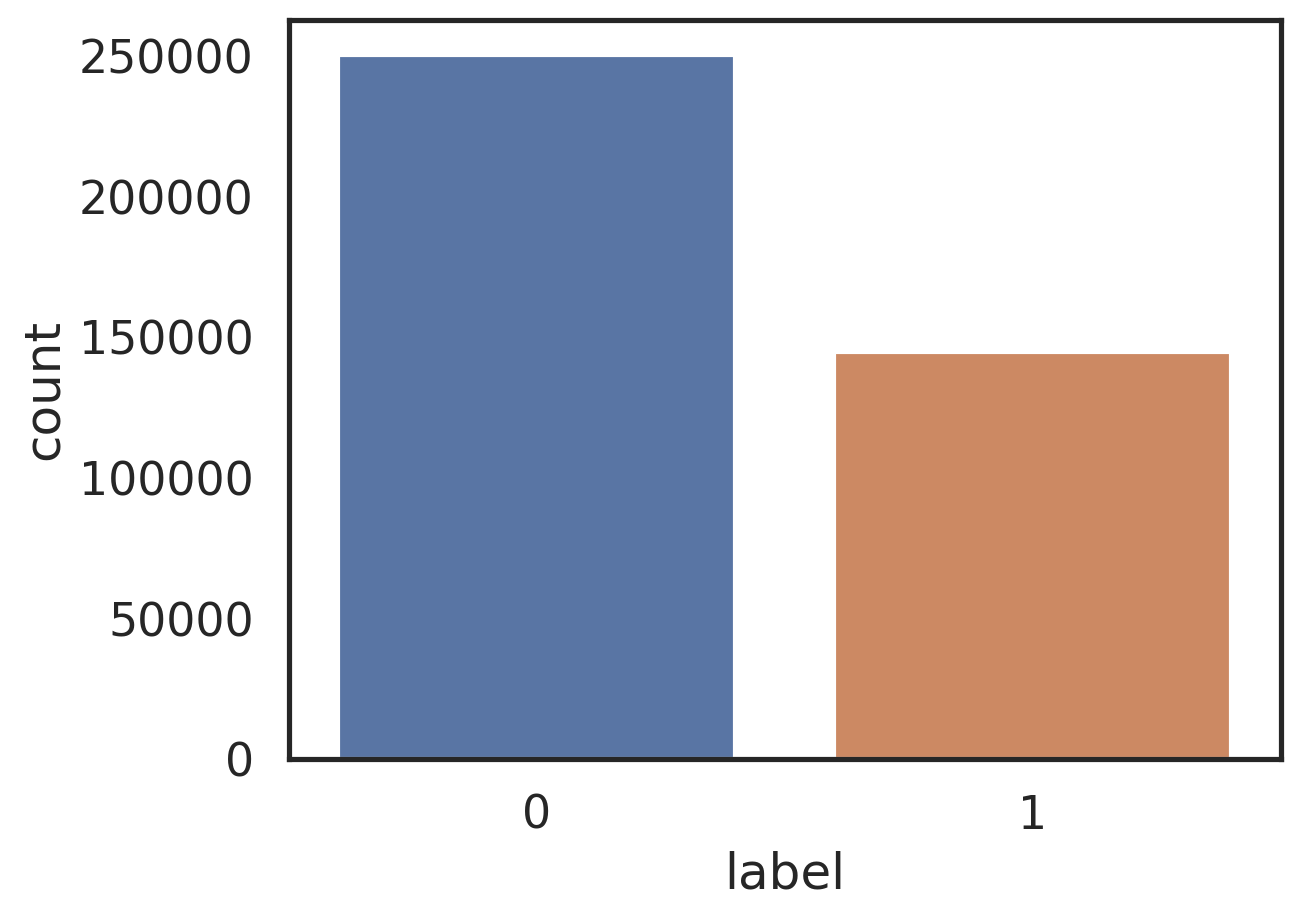

In [45]:
sns.countplot(train_df, x="label")

In [46]:
val_df.label.value_counts()

0    36354
1    19148
Name: label, dtype: int64

In [47]:
(val_df.label==0).sum()/val_df.shape[0]

0.6550034233000612

In [48]:
(val_df.label==1).sum()/val_df.shape[0]

0.3449965766999387

## DataLoaders

In [49]:
# torch.save(predictions, 'dev_preds.pt')

In [50]:
# The outputs are logits. Use softmax to convert them into probabilities
dev_preds = torch.load(OUT_DIR / 'dev_preds.pt')
all_probabilities = []
for outputs in dev_preds:
    probabilities = torch.nn.functional.softmax(outputs, dim=-1)
    # Append probabilities to list
    all_probabilities.extend(probabilities[:, 1].tolist())

In [51]:
dev_df["proba"] = all_probabilities

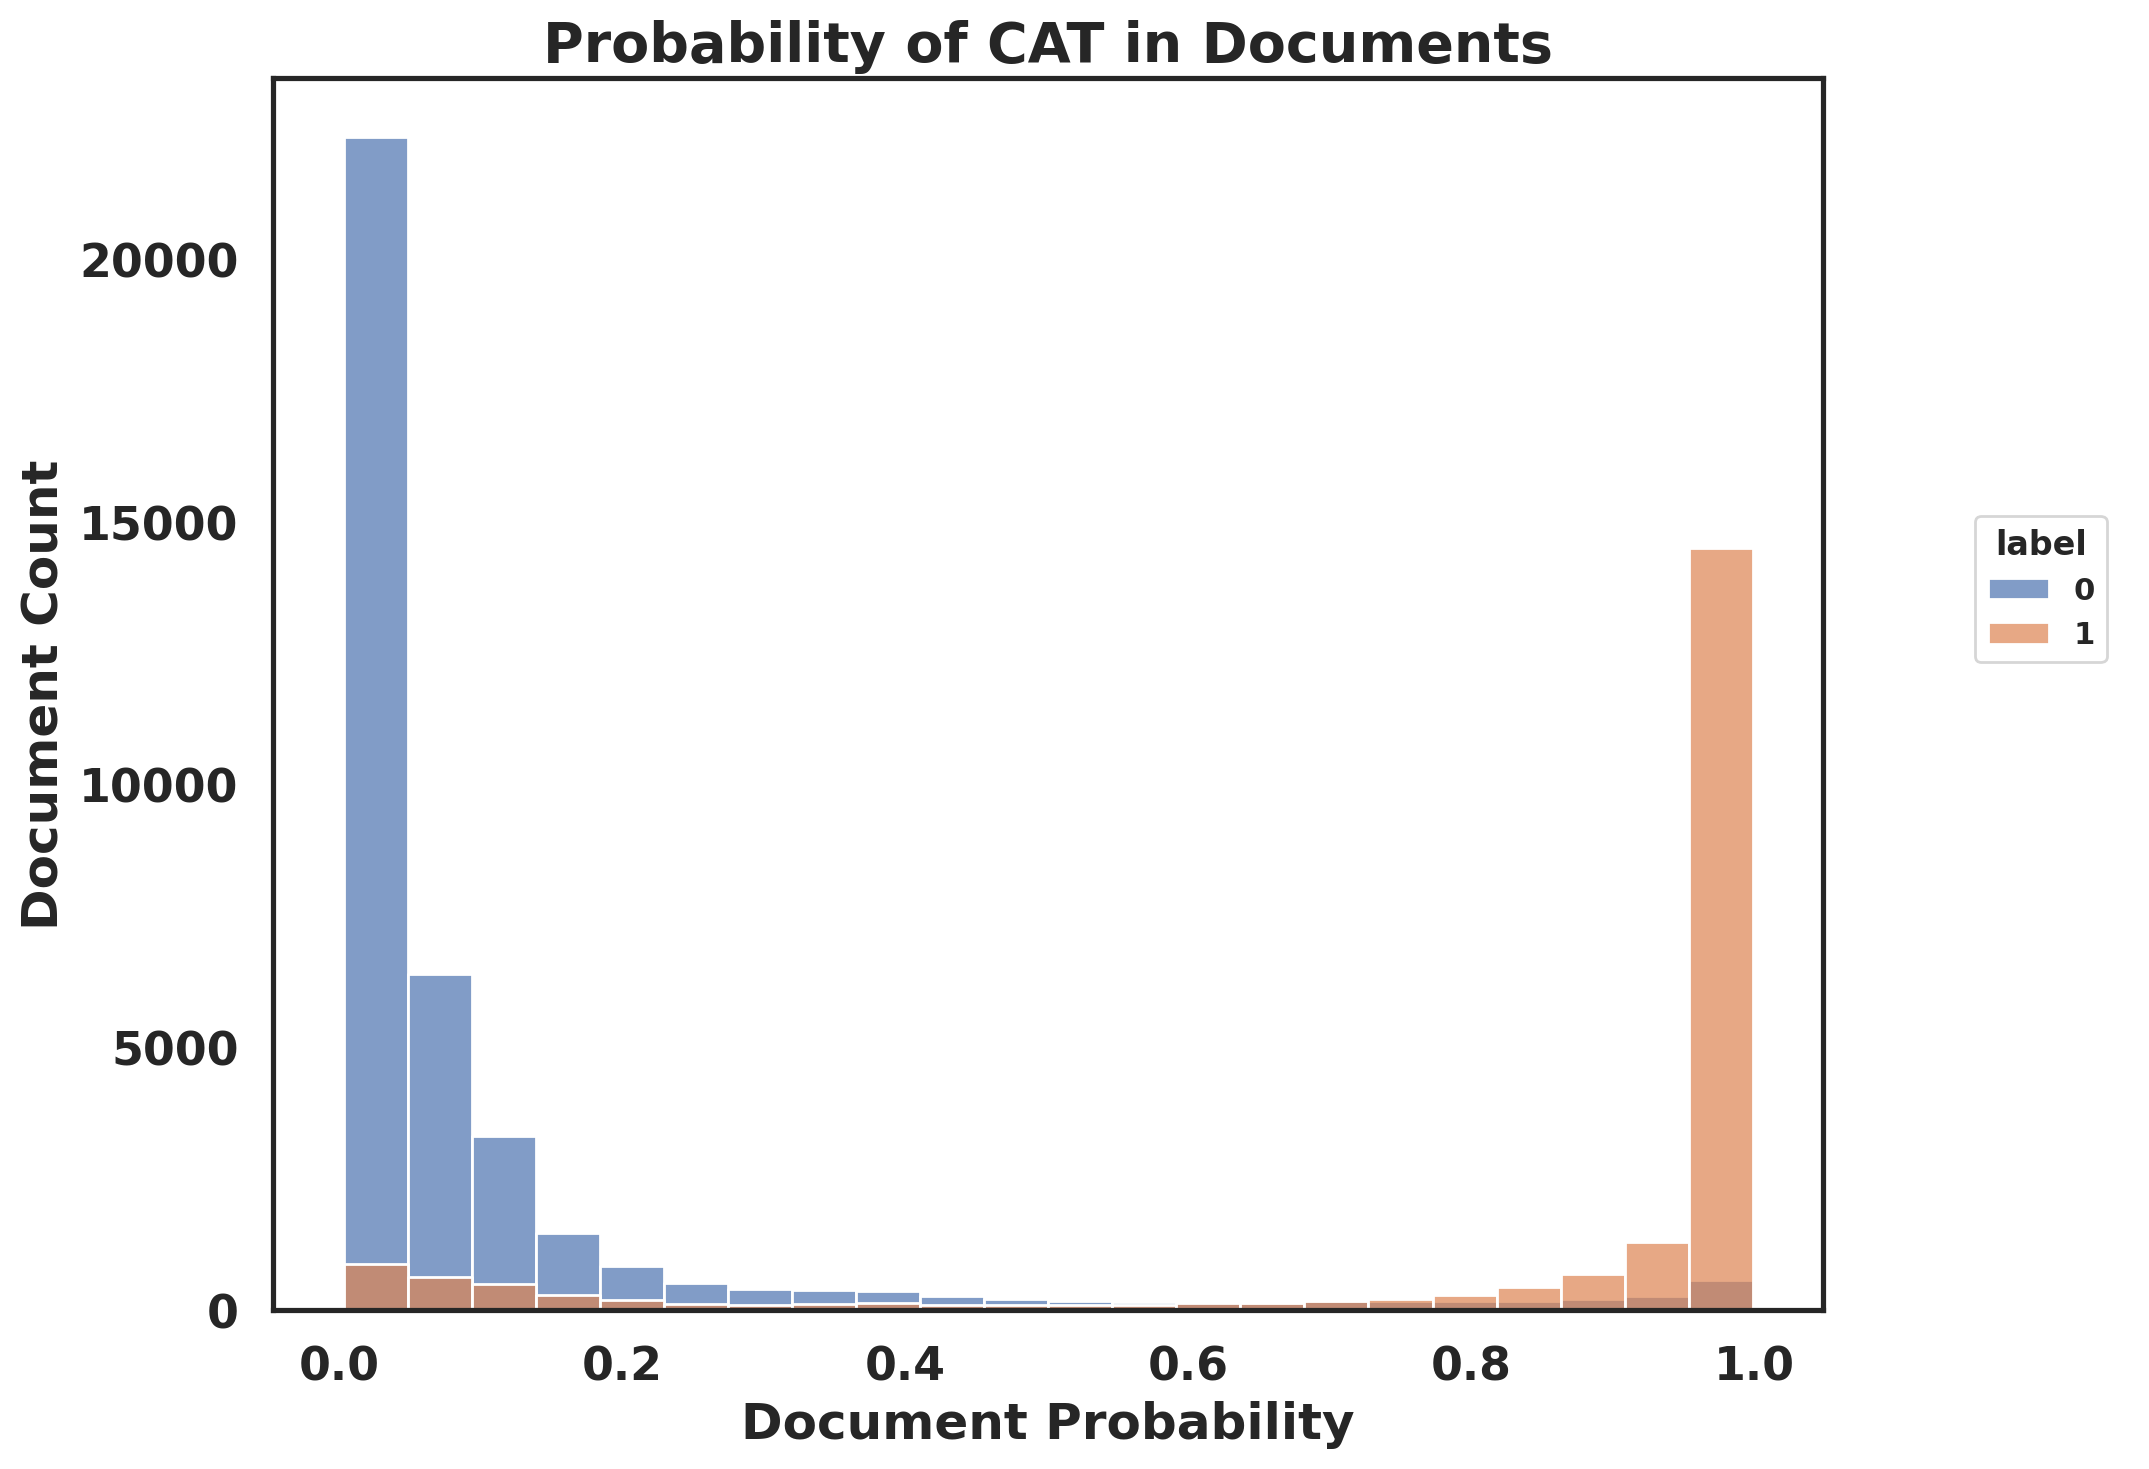

In [54]:
font = {'family' : 'sans',
        'weight' : 'bold',
        'size'   : 22}

mpl.rc('font', **font)

import seaborn.objects as so
from matplotlib import style
from seaborn import axes_style


f, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel("a", fontweight='bold')
ax.set_ylabel("a", fontweight='bold')

plot_df = dev_df.copy()
plot_df["label"] = plot_df["label"].astype(str)

(so.Plot(data=plot_df, x="proba", color="label")
.add(so.Bars(), so.Hist())
.theme({**axes_style("whitegrid"),
        # "legend.loc": "best",
        "font.weight": "bold",
        "font.size": 40,
        "axes.titlesize" : 20,
        "axes.titleweight": "bold"
       })
.on(ax)
.label(
    x="Document Probability",
    y="Document Count",
    # color=str.capitalize,
    title="Probability of CAT in Documents",
    fontweight="bold"
)
.save("notes_prediction_probabilities.svg",
       dpi=300,
       format="svg",
       bbox_inches="tight",
     )
);

In [57]:
dev_df.label.astype(str).value_counts()

0    38880
1    21254
Name: label, dtype: int64

<Axes: xlabel='label', ylabel='count'>

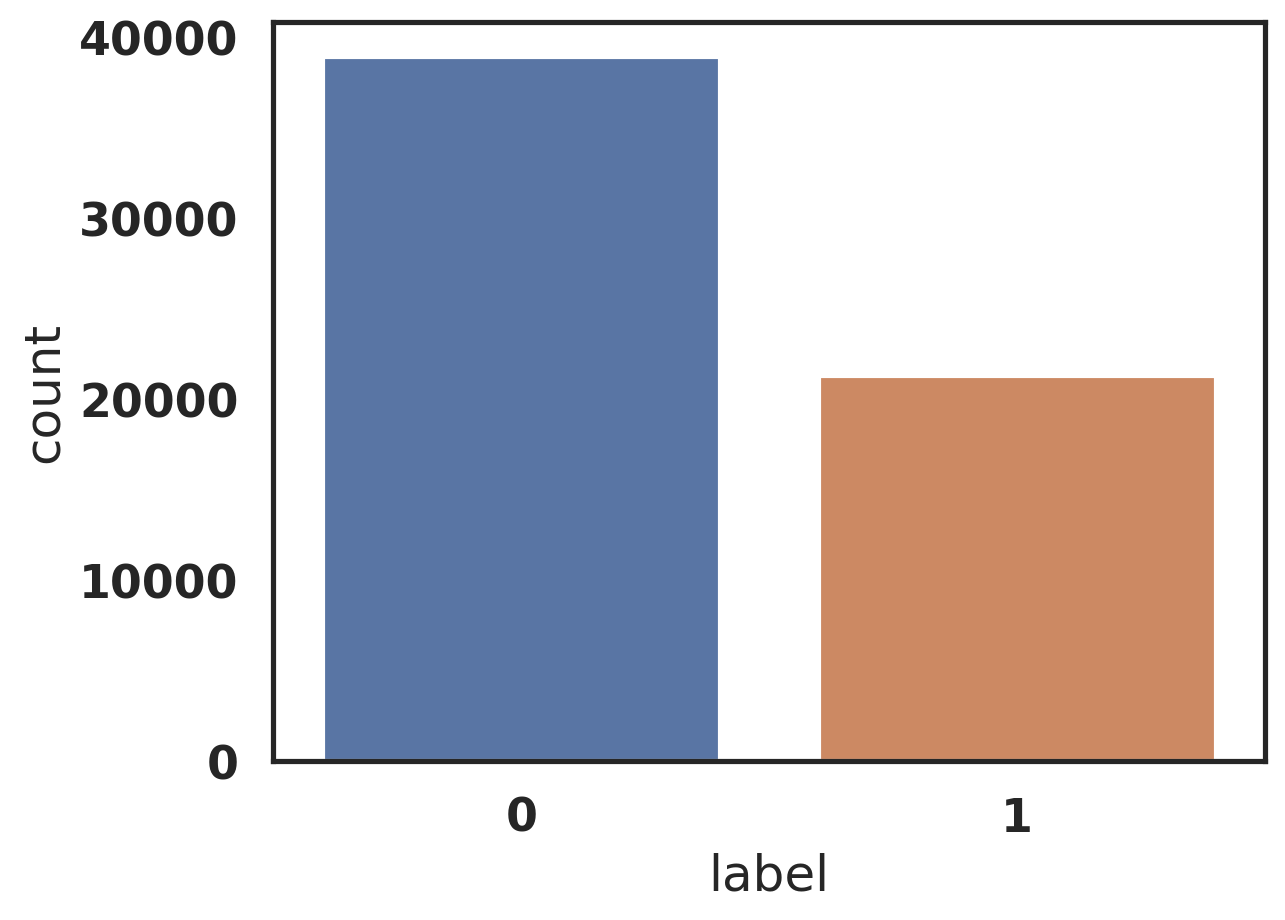

In [58]:
sns.countplot(x=dev_df.label.astype(str))

In [33]:
dev_df.to_csv(OUT_DIR / "predictions_model_abstract_dev.csv", index=None)